Visualisation notebook for Resting Times (For this part I used co-pilot)

In [1]:
#importing 
from CommonFunctions import * 
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

df_path = '/Users/nubia/Desktop/Thesis_2.0/dataset/df.joblib'
merged_df_path = '/Users/nubia/Desktop/Thesis_2.0/dataset/merged_df.joblib'

import joblib 

df = joblib.load(df_path)
merged_df = joblib.load(merged_df_path)

Found 211 resting events in Trial_1 (boundary=0.02).


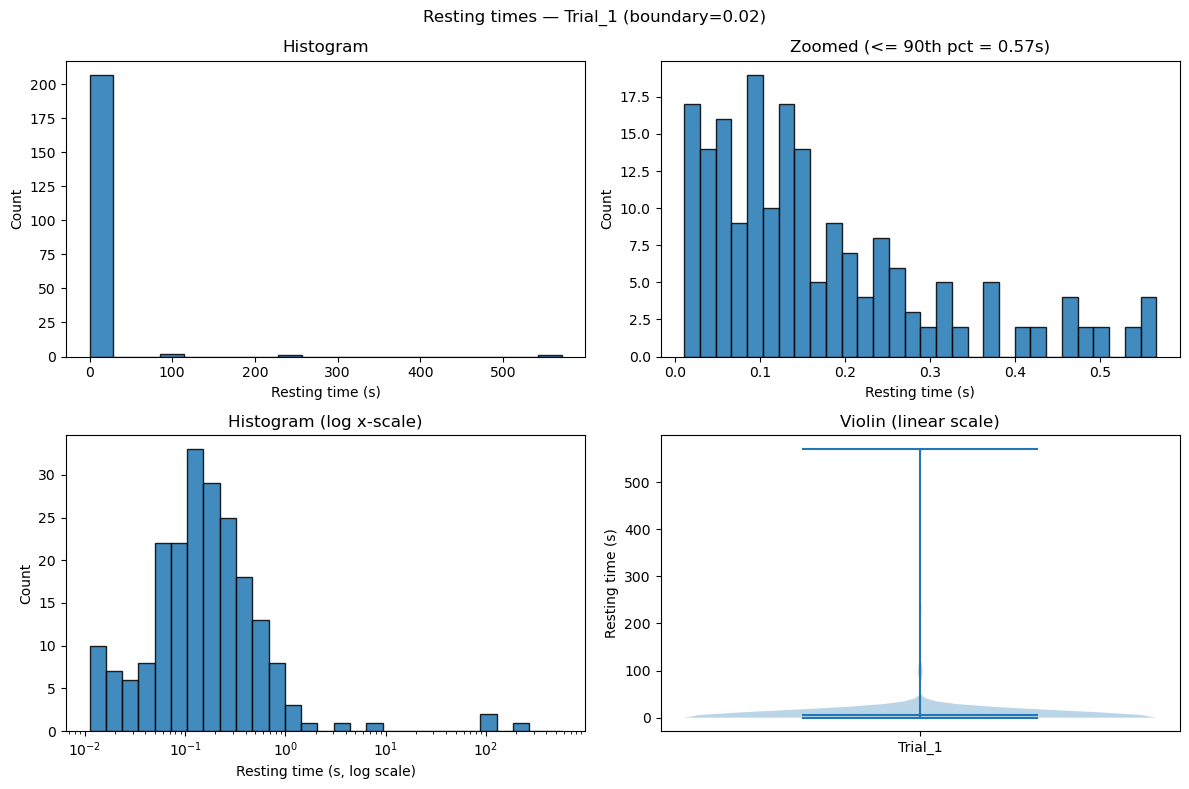

In [ ]:
boundary = 0.02
trial_key = 'Trial_1'
trial_df = merged_df[trial_key]

def resting_times_for_track(x, y, z, t, boundary=0.02):
    x = np.asarray(x); y = np.asarray(y); z = np.asarray(z); t = np.asarray(t)
    if t.size < 2: # Only returns tracks that have more than 1 timepoint 
        return []
    mask = landing_area_array(x, y, z, boundary=boundary)  # boolean array
    if not np.any(mask):
        return []
    # Find contiguous True segments
    changes = np.diff(np.concatenate(([0], mask.astype(int), [0])))
    starts = np.where(changes == 1)[0]
    ends   = np.where(changes == -1)[0]

    durations = []
    for s, e in zip(starts, ends):
        # duration over indices [s, e-1]
        dur = float(t[e-1] - t[s]) if e - s > 1 else 0.0
        if dur > 0: # Removing all the one-sample durations 
            durations.append(dur)
    return durations


# Collect resting times across all merged tracks in Trial_1
all_resting_times = []
for idx, row in trial_df.iterrows():
    x, y, z, t = row['x'], row['y'], row['z'], row['time']
    if all(v is not None for v in (x, y, z, t)):
        all_resting_times.extend(resting_times_for_track(x, y, z, t, boundary=boundary))

print(f'Found {len(all_resting_times)} resting events in {trial_key} (boundary={boundary}).')


# Plot panel
if all_resting_times:
    dur = np.asarray(all_resting_times)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # 1) Normal histogram (more bins)
    bins_normal = 20 if np.max(dur) > 0 else 10
    axes[0, 0].hist(dur, bins=bins_normal, edgecolor='black', alpha=0.85)
    axes[0, 0].set_title('Histogram')
    axes[0, 0].set_xlabel('Resting time (s)')
    axes[0, 0].set_ylabel('Count')

    # 2) Zoomed-in histogram (<= 90th percentile)
    zoom_max = np.quantile(dur, 0.9)
    dur_zoom = dur[dur <= zoom_max]
    axes[0, 1].hist(dur_zoom, bins=30, edgecolor='black', alpha=0.85)
    axes[0, 1].set_title(f'Zoomed (<= 90th pct = {zoom_max:.2f}s)')
    axes[0, 1].set_xlabel('Resting time (s)')
    axes[0, 1].set_ylabel('Count')

    # 3) Log-scale histogram
    dur_pos = dur[dur > 0]
    if dur_pos.size > 0:
        if dur_pos.min() < dur_pos.max():
            bins_log = np.logspace(np.log10(dur_pos.min()), np.log10(dur_pos.max()), 30)
        else:
            # fall back if all values are identical
            bins_log = 10
        axes[1, 0].hist(dur_pos, bins=bins_log, edgecolor='black', alpha=0.85)
        axes[1, 0].set_xscale('log')
        axes[1, 0].set_title('Histogram (log x-scale)')
        axes[1, 0].set_xlabel('Resting time (s, log scale)')
        axes[1, 0].set_ylabel('Count')
    else:
        axes[1, 0].text(0.5, 0.5, 'No positive durations for log scale', ha='center', va='center')
        axes[1, 0].set_axis_off()

    # 4) Log-scale violin plot
    # 4) Violin plot (linear scale)
    if dur.size > 0:
        axes[1, 1].violinplot([dur], showmeans=True, showextrema=True)
        axes[1, 1].set_xticks([1])
        axes[1, 1].set_xticklabels([trial_key])
        axes[1, 1].set_title('Violin (linear scale)')
        axes[1, 1].set_ylabel('Resting time (s)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No durations available', ha='center', va='center')
        axes[1, 1].set_axis_off()

    fig.suptitle(f'Resting times — {trial_key} (boundary={boundary})', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print('No resting times detected for the given boundary.')


Visualisation of the time spend in boundary (NOT NEEDED AT AL BUT FUN)

In [3]:
%pip install ipywidgets ipympl
%matplotlib widget
import importlib, InteractiveVisualization as IV
importlib.reload(IV)
from InteractiveVisualization import show_track3_trial1
show_track3_trial1(boundary=0.02)

Note: you may need to restart the kernel to use updated packages.


RuntimeError: 'widget' is not a recognised GUI loop or backend name

NOW FOR ALL THE TRIALS 

['Trial_1', 'Trial_2', 'Trial_3', 'Trial_4', 'Trial_5', 'Trial_6', 'Trial_7', 'Trial_8', 'Trial_9', 'Trial_10', 'Trial_11', 'Trial_12', 'Trial_13', 'Trial_14', 'Trial_15', 'Trial_16', 'Trial_17', 'Trial_18', 'Trial_19', 'Trial_20', 'Trial_21', 'Trial_22', 'Trial_23', 'Trial_24', 'Trial_25', 'Trial_26', 'Trial_27', 'Trial_28', 'Trial_29', 'Trial_30', 'Trial_31', 'Trial_32', 'Trial_33', 'Trial_34', 'Trial_35', 'Trial_36', 'Trial_37', 'Trial_38', 'Trial_39', 'Trial_40', 'Trial_41', 'Trial_42', 'Trial_43', 'Trial_44', 'Trial_45', 'Trial_46', 'Trial_47', 'Trial_48', 'Trial_49', 'Trial_50', 'Trial_51', 'Trial_52', 'Trial_53', 'Trial_54', 'Trial_55', 'Trial_56', 'Trial_57', 'Trial_58', 'Trial_59', 'Trial_60', 'Trial_61', 'Trial_62', 'Trial_63', 'Trial_64']
[Trial_1] Found 211 resting events (boundary=0.02).
[Trial_2] Found 338 resting events (boundary=0.02).
[Trial_3] Found 221 resting events (boundary=0.02).
[Trial_4] Found 184 resting events (boundary=0.02).
[Trial_5] Found 598 resting even

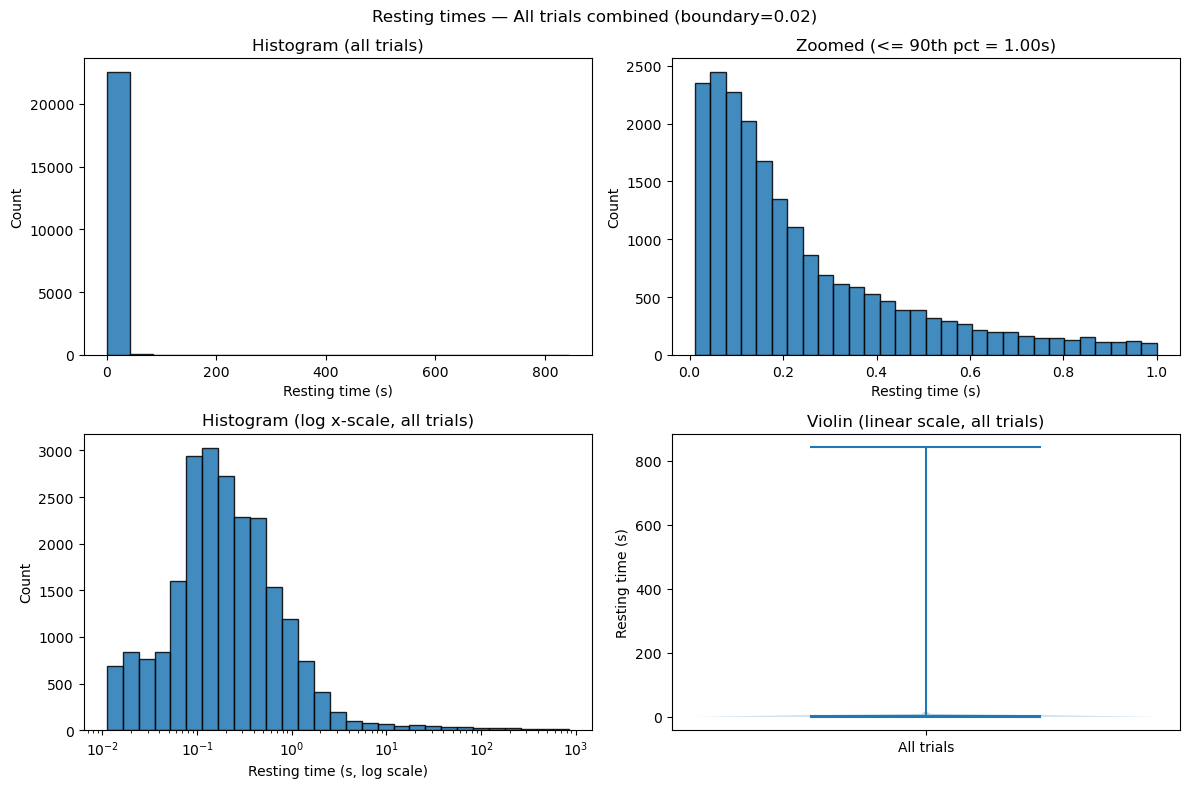

In [ ]:
boundary = 0.02

def resting_times_for_track(x, y, z, time, boundary=0.02):
    x = np.asarray(x); y = np.asarray(y); z = np.asarray(z); time = np.asarray(time)
    if time.size < 2:
        return []
    mask = landing_area_array(x, y, z, boundary=boundary)  # boolean array
    if not np.any(mask):
        return []
    changes = np.diff(np.concatenate(([0], mask.astype(int), [0])))
    starts = np.where(changes == 1)[0]
    ends   = np.where(changes == -1)[0]
    durations = []
    for s, e in zip(starts, ends):
        dur = float(time[e-1] - time[s]) if e - s > 1 else 0.0
        if dur > 0:
            durations.append(dur)
    return durations

# Collect all trial keys and sort numerically (Trial_1, Trial_2, ...)
trial_keys = []
for key in merged_df.keys():
    # Only keep string keys like "Trial_1", "Trial_2", ...
    if isinstance(key, str) and key.startswith("Trial_"):
        trial_keys.append(key)

def _trial_idx(k):
    return int(k.split('_')[1])
trial_keys = sorted(trial_keys, key=_trial_idx)

all_resting_times = []
durations_by_trial = {}

for trial_key in trial_keys:
    trial_df = merged_df[trial_key]

    trial_durations = []
    for _, row in trial_df.iterrows():
        x, y, z, time = row.get('x'), row.get('y'), row.get('z'), row.get('time')
        trial_durations.extend(resting_times_for_track(x, y, z, time, boundary=boundary))
    durations_by_trial[trial_key] = trial_durations
    all_resting_times.extend(trial_durations)
    print(f'[{trial_key}] Found {len(trial_durations)} resting events (boundary={boundary}).')

print(f'[ALL TRIALS] Total resting events: {len(all_resting_times)}')

if all_resting_times:
    dur = np.asarray(all_resting_times)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # 1) Normal histogram (same bins as before)
    bins_normal = 20 if np.max(dur) > 0 else 10
    axes[0, 0].hist(dur, bins=bins_normal, edgecolor='black', alpha=0.85)
    axes[0, 0].set_title('Histogram (all trials)')
    axes[0, 0].set_xlabel('Resting time (s)')
    axes[0, 0].set_ylabel('Count')

    # 2) Zoomed-in histogram (<= 90th percentile)
    zoom_max = np.quantile(dur, 0.9)
    dur_zoom = dur[dur <= zoom_max]
    axes[0, 1].hist(dur_zoom, bins=30, edgecolor='black', alpha=0.85)
    axes[0, 1].set_title(f'Zoomed (<= 90th pct = {zoom_max:.2f}s)')
    axes[0, 1].set_xlabel('Resting time (s)')
    axes[0, 1].set_ylabel('Count')

    # 3) Log-scale histogram
    dur_pos = dur[dur > 0]
    if dur_pos.size > 0:
        if dur_pos.min() < dur_pos.max():
            bins_log = np.logspace(np.log10(dur_pos.min()), np.log10(dur_pos.max()), 30)
        else:
            bins_log = 10
        axes[1, 0].hist(dur_pos, bins=bins_log, edgecolor='black', alpha=0.85)
        axes[1, 0].set_xscale('log')
        axes[1, 0].set_title('Histogram (log x-scale, all trials)')
        axes[1, 0].set_xlabel('Resting time (s, log scale)')
        axes[1, 0].set_ylabel('Count')
    else:
        axes[1, 0].text(0.5, 0.5, 'No positive durations for log scale', ha='center', va='center')
        axes[1, 0].set_axis_off()

    # 4) Violin plot (linear scale, pooled)
    axes[1, 1].violinplot([dur], showmeans=True, showextrema=True)
    axes[1, 1].set_xticks([1])
    axes[1, 1].set_xticklabels(['All trials'])
    axes[1, 1].set_title('Violin (linear scale, all trials)')
    axes[1, 1].set_ylabel('Resting time (s)')

    fig.suptitle(f'Resting times — All trials combined (boundary={boundary})', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print('No resting times detected across all trials for the given boundary.')

       

In [ ]:

if all_resting_times:
    dur = np.asarray(all_resting_times)

    # --- Summary stats ---
    n = dur.size
    mean = float(np.mean(dur))
    median = float(np.median(dur))
    std = float(np.std(dur, ddof=1)) if n > 1 else 0.0
    p5, p25, p75, p95 = np.quantile(dur, [0.05, 0.25, 0.75, 0.95])
    dmin, dmax = float(np.min(dur)), float(np.max(dur))

    print(f'Count: {n}')
    print(f'Mean: {mean:.3f} s, Median: {median:.3f} s, Std: {std:.3f} s')
    print(f'5th–95th pct: {p5:.3f}–{p95:.3f} s, IQR (25–75): {p25:.3f}–{p75:.3f} s')
    print(f'Min–Max: {dmin:.3f}–{dmax:.3f} s')

 

Count: 22680
Mean: 1.807 s, Median: 0.189 s, Std: 20.062 s
5th–95th pct: 0.022–1.744 s, IQR (25–75): 0.089–0.444 s
Min–Max: 0.011–843.544 s


Resting points found: 24286


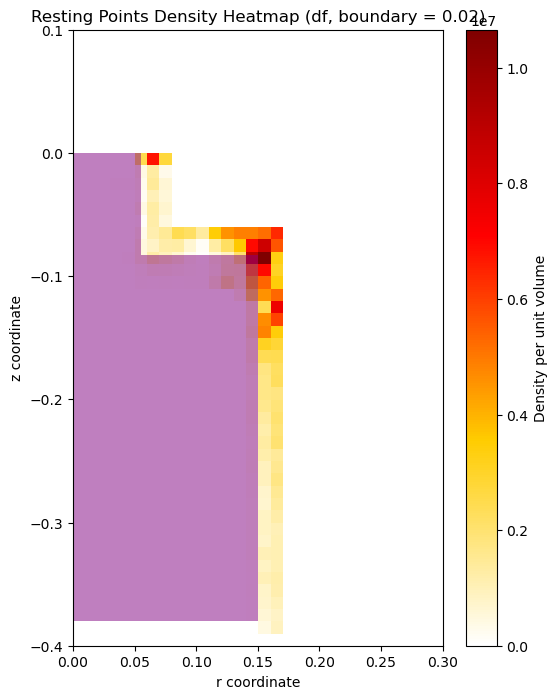

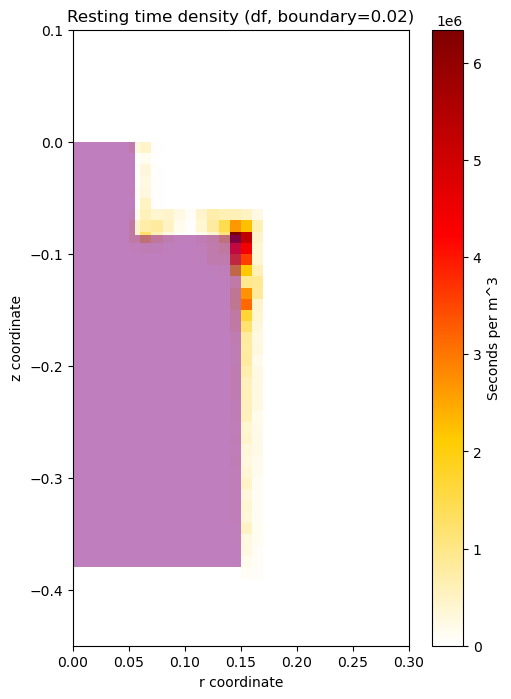

In [ ]:

# ======== Heatmap of resting points (same structure as RestingPoints.ipynb cell 14) ======== #
from CommonFunctions import resting_times, density_matrix_2d_normalized, plot_density_heatpmap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

data = merged_df                    
dataset_name = 'merges_df'
boundary = 0.02             
num_trials = 3

# ======== 1. Get resting points ======== #
all_x, all_y, all_z, all_dur = resting_times(data, start_trial_num=1, end_trial_num=num_trials + 1, boundary = boundary)
print("Resting times found:", len(all_x))
print("Sample resting points (x, y, z, duration):", list(zip(all_x, all_y, all_z, all_dur))[:5])
print("Average resting duration:", np.mean(all_dur))

# ======== 2. Compute density matrix ======== #
density_matrix, r_edges, z_edges = density_matrix_2d_weighted_normalized(all_x, all_y, all_z)
 
# ======== 3. Plot heatmap with trap overlay ======== #
plot_density_heatpmap_restingtime(density_matrix, r_edges, z_edges, dataset_name = dataset_name, boundary=boundary)
